In [11]:
import kagglehub
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print(path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
/kaggle/input/new-plant-diseases-dataset


In [12]:
import os

base_path = "/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2"

for root, dirs, files in os.walk(base_path):
    depth = root.replace(base_path, '').count(os.sep)
    if depth <= 2:
        print(f"{'  ' * depth}{root} -> {len(files)} files, {len(dirs)} subfolders")

In [13]:
import os

# Assuming 'path' variable is available from the previous cell's execution,
# which holds the base directory of the downloaded dataset: /kaggle/input/new-plant-diseases-dataset
# If 'path' is not globally available, uncomment the line below:
# path = '/kaggle/input/new-plant-diseases-dataset'

train_dir = os.path.join(path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "train")
valid_dir = os.path.join(path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "valid")


print("Classes:", len(os.listdir(train_dir)))
print(os.listdir(train_dir)[:5])

Classes: 38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


In [14]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"{len(class_names)} classes")

preprocess_input = tf.keras.applications.efficientnet.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

print("Data pipeline ready.")

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
38 classes
Data pipeline ready.


In [15]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze for phase 1

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(38, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 361s 151ms/step - accuracy: 0.8934 - loss: 0.4635 - val_accuracy: 0.9601 - val_loss: 0.1607 - learning_rate: 0.0010
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 123s 56ms/step - accuracy: 0.9529 - loss: 0.1676 - val_accuracy: 0.9711 - val_loss: 0.1062 - learning_rate: 0.0010
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 158s 63ms/step - accuracy: 0.9607 - loss: 0.1309 - val_accuracy: 0.9759 - val_loss: 0.0880 - learning_rate: 0.0010
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.9655 - loss: 0.1131 - val_accuracy: 0.9789 - val_loss: 0.0747 - learning_rate: 0.0010
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.9679 - loss: 0.1025 - val_accuracy: 0.9797 - val_loss: 0.0702 - learning_rate: 0.0010
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 160s 71ms/step - accuracy: 0.9688 - loss: 0.0968 - val_accuracy: 0.9791 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 

In [17]:
from google.colab import drive
drive.mount('/content/drive')
model.save('/content/drive/MyDrive/plant_disease_model_phase1.keras')
print("Saved.")

Mounted at /content/drive
Saved.


In [18]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much lower LR than phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks2 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model_final.keras', monitor='val_accuracy', save_best_only=True),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks2
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 188s 73ms/step - accuracy: 0.9101 - loss: 0.2898 - val_accuracy: 0.9717 - val_loss: 0.0860
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 134s 61ms/step - accuracy: 0.9538 - loss: 0.1395 - val_accuracy: 0.9809 - val_loss: 0.0599
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 135s 61ms/step - accuracy: 0.9664 - loss: 0.1007 - val_accuracy: 0.9842 - val_loss: 0.0492
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.9731 - loss: 0.0793 - val_accuracy: 0.9867 - val_loss: 0.0417
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 137s 62ms/step - accuracy: 0.9784 - loss: 0.0654 - val_accuracy: 0.9871 - val_loss: 0.0372
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 132s 60ms/step - accuracy: 0.9813 - loss: 0.0569 - val_accuracy: 0.9893 - val_loss: 0.0331
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 132s 60ms/step - accuracy: 0.9835 - loss: 0.0489 - val_accuracy: 0.9899 - val_loss: 0.0304
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 132s 60ms/step - accuracy: 

In [19]:
model.save('/content/drive/MyDrive/plant_disease_model_final.keras')
print("Saved.")

Saved.


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       504
                                 Apple___Black_rot       1.00      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       1.00      1.00      1.00       502
                               Blueberry___healthy       1.00      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.93      0.95       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.94      0.99      0.

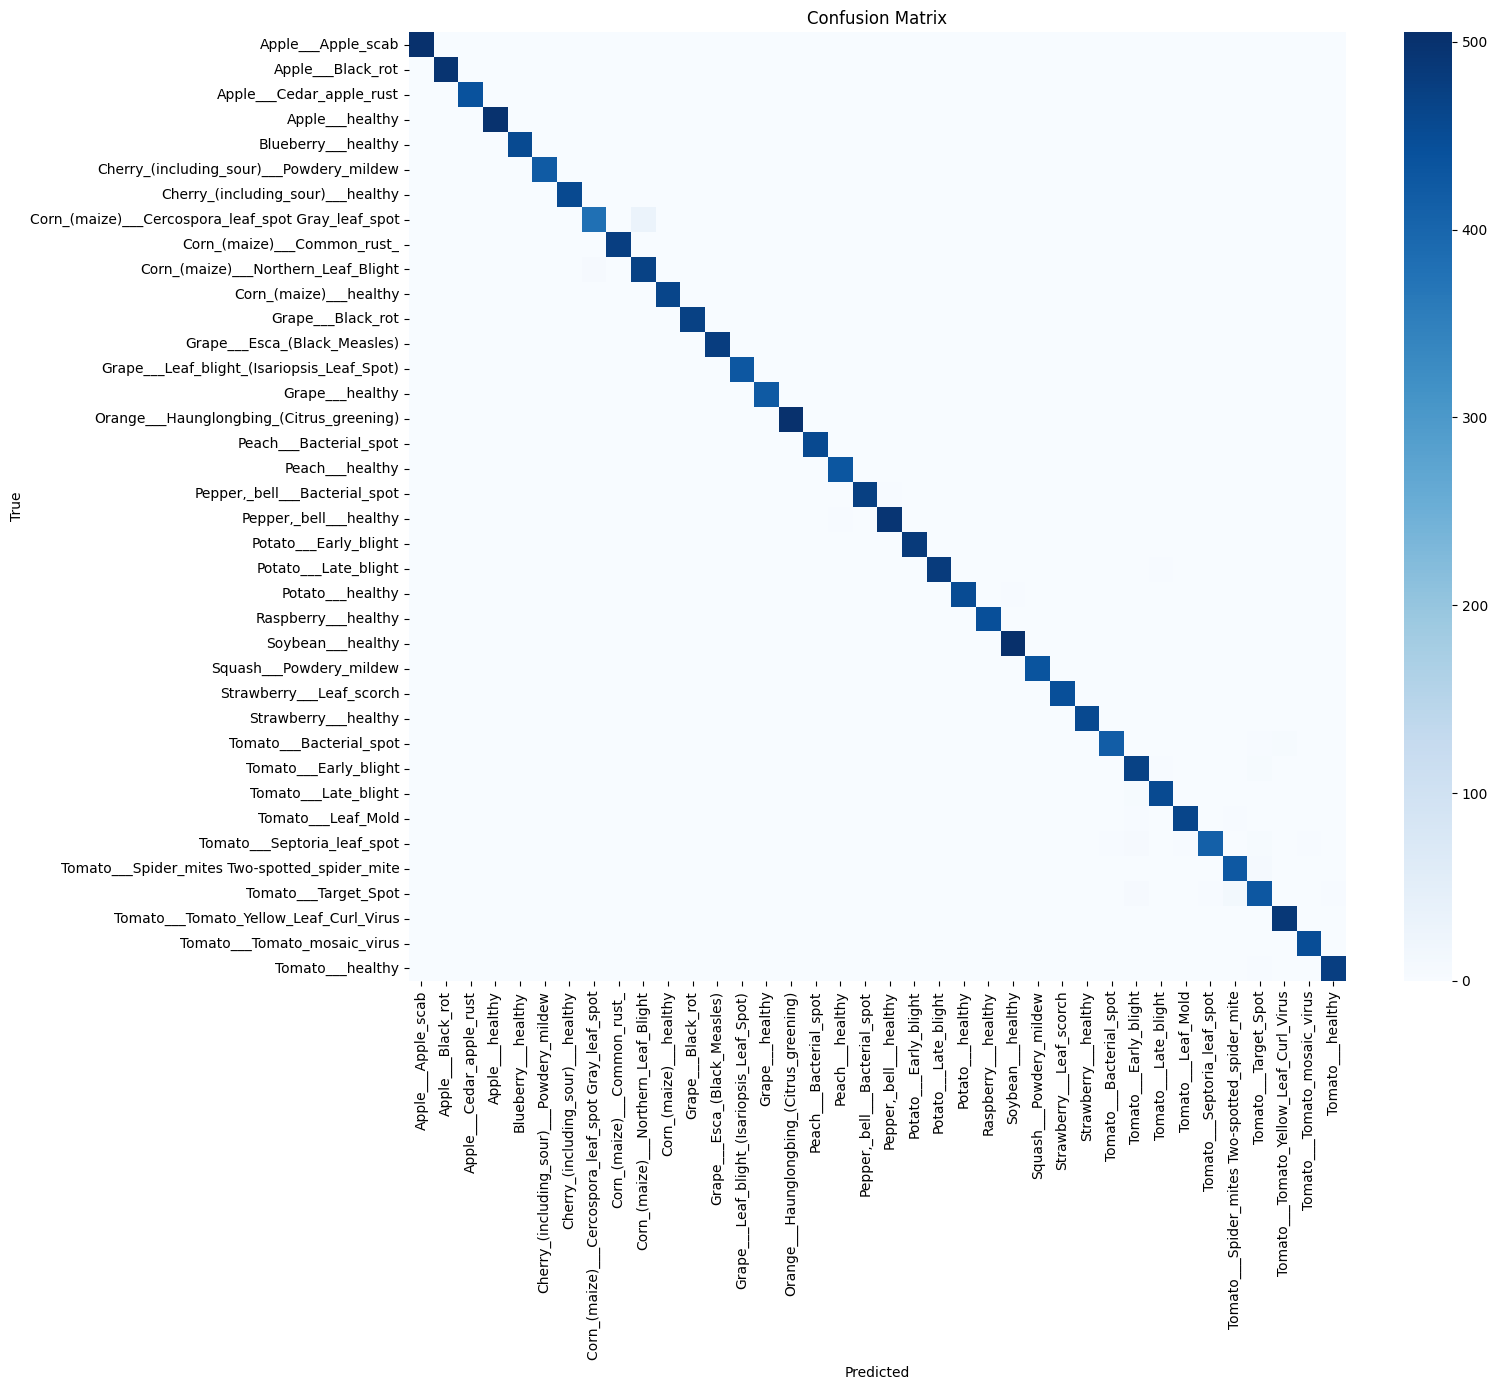

In [20]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png')
plt.show()


In [21]:
import pandas as pd

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('/content/drive/MyDrive/classification_report.csv')
report_df.round(3)

,precision,recall,f1-score,support
Apple___Apple_scab,0.996,0.996,0.996,504.000
Apple___Black_rot,0.996,1.000,0.998,497.000
Apple___Cedar_apple_rust,0.995,0.995,0.995,440.000
Apple___healthy,1.000,0.998,0.999,502.000
Blueberry___healthy,1.000,1.000,1.000,454.000
Cherry_(including_sour)___Powdery_mildew,1.000,1.000,1.000,421.000
Cherry_(including_sour)___healthy,1.000,1.000,1.000,456.000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.982,0.927,0.954,410.000
Corn_(maize)___Common_rust_,1.000,1.000,1.000,477.000
Corn_(maize)___Northern_Leaf_Blight,0.940,0.985,0.962,477.000


Using conv layer: top_conv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
Predicted: Soybean___healthy True: Soybean___healthy


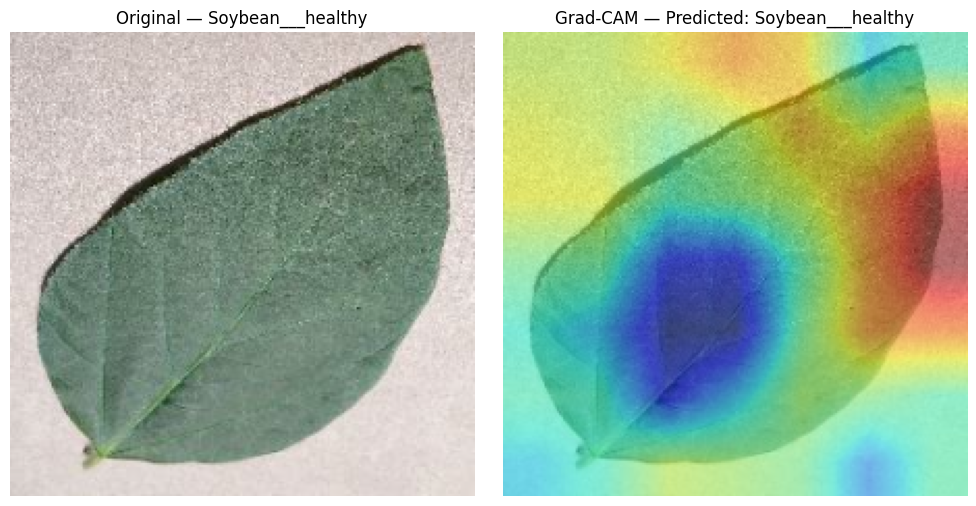

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# find the actual last conv layer name inside base_model
last_conv_layer_name = None
for layer in base_model.layers[::-1]:
    if 'conv' in layer.name.lower() and len(layer.output.shape) == 4:
        last_conv_layer_name = layer.name
        break
print("Using conv layer:", last_conv_layer_name)

# build a model that exposes base_model's conv output alongside its final feature output
grad_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
)

# grab the head layers from your outer model to continue the forward pass
gap_layer = model.layers[-3]      # GlobalAveragePooling2D
dropout_layer = model.layers[-2]  # Dropout
dense_layer = model.layers[-1]    # Dense (final classifier)

def get_gradcam(img_array, pred_class):
    with tf.GradientTape() as tape:
        conv_output, base_output = grad_model(img_array)
        x = gap_layer(base_output)
        x = dropout_layer(x, training=False)
        preds = dense_layer(x)
        class_channel = preds[:, pred_class]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# pick a sample image (reuse the one from before)
for images, labels in val_ds.take(1):
    sample_img = images[0:1]
    true_label = np.argmax(labels[0].numpy())
    break

pred = model.predict(sample_img)
pred_class = np.argmax(pred[0])
print("Predicted:", class_names[pred_class], "True:", class_names[true_label])

heatmap = get_gradcam(sample_img, pred_class)

# display
img_display = (sample_img[0].numpy() - sample_img[0].numpy().min()) / (sample_img[0].numpy().max() - sample_img[0].numpy().min())
heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title(f"Original — {class_names[true_label]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_display)
plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
plt.title(f"Grad-CAM — Predicted: {class_names[pred_class]}")
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gradcam_sample.png')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted: Corn_(maize)___Common_rust_ True: Corn_(maize)___Common_rust_


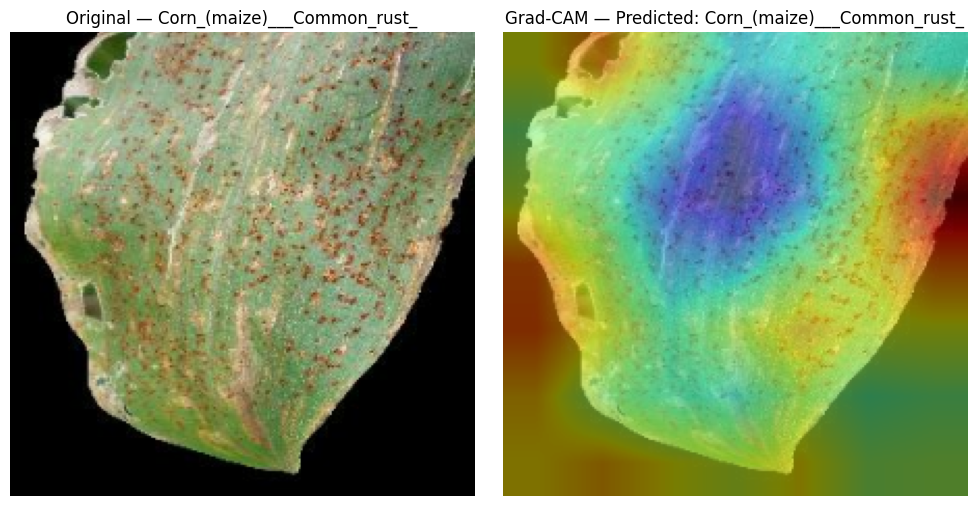

In [25]:
# find a diseased (non-healthy) sample to test localization properly
for images, labels in val_ds.unbatch().batch(1):
    true_label = np.argmax(labels[0].numpy())
    if 'healthy' not in class_names[true_label].lower():
        sample_img = images
        break

pred = model.predict(sample_img)
pred_class = np.argmax(pred[0])
print("Predicted:", class_names[pred_class], "True:", class_names[true_label])

heatmap = get_gradcam(sample_img, pred_class)

img_display = (sample_img[0].numpy() - sample_img[0].numpy().min()) / (sample_img[0].numpy().max() - sample_img[0].numpy().min())
heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title(f"Original — {class_names[true_label]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_display)
plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
plt.title(f"Grad-CAM — Predicted: {class_names[pred_class]}")
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gradcam_diseased_sample.png')
plt.show()

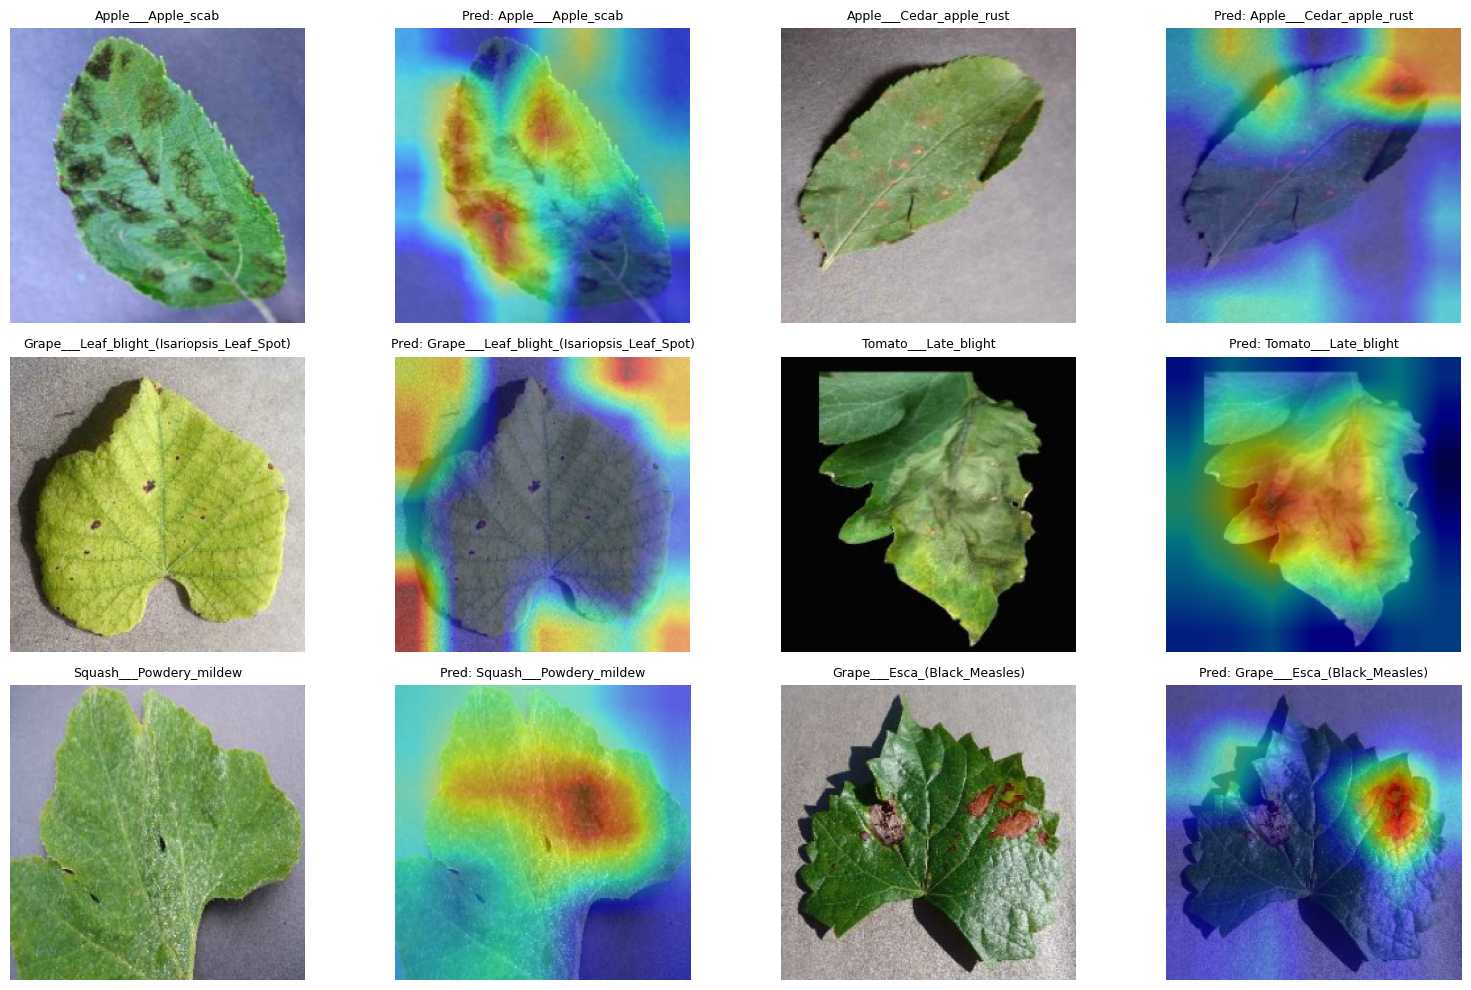

In [26]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
sample_count = 0
for images, labels in val_ds.unbatch().batch(1):
    if sample_count >= 6:
        break
    true_label = np.argmax(labels[0].numpy())
    if 'healthy' in class_names[true_label].lower():
        continue
    pred = model.predict(images, verbose=0)
    pred_class = np.argmax(pred[0])
    heatmap = get_gradcam(images, pred_class)
    img_display = (images[0].numpy() - images[0].numpy().min()) / (images[0].numpy().max() - images[0].numpy().min())
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()
    r, c = sample_count // 2, (sample_count % 2) * 2
    axes[r, c].imshow(img_display); axes[r, c].set_title(class_names[true_label], fontsize=9); axes[r, c].axis('off')
    axes[r, c+1].imshow(img_display); axes[r, c+1].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    axes[r, c+1].set_title(f"Pred: {class_names[pred_class]}", fontsize=9); axes[r, c+1].axis('off')
    sample_count += 1
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gradcam_grid.png')
plt.show()

In [27]:
def faithfulness_test(images_batch, num_samples=20):
    drops = []
    count = 0
    for images, labels in val_ds.unbatch().batch(1):
        if count >= num_samples:
            break
        true_label = np.argmax(labels[0].numpy())
        if 'healthy' in class_names[true_label].lower():
            continue

        orig_pred = model.predict(images, verbose=0)
        pred_class = np.argmax(orig_pred[0])
        orig_confidence = orig_pred[0][pred_class]

        heatmap = get_gradcam(images, pred_class)
        heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()

        # mask out the top-activated region (threshold at 70th percentile)
        threshold = np.percentile(heatmap_resized, 70)
        mask = (heatmap_resized > threshold).astype(np.float32)[..., np.newaxis]

        masked_img = images.numpy().copy()
        masked_img[0] = masked_img[0] * (1 - mask)  # zero out the hot region

        masked_pred = model.predict(masked_img, verbose=0)
        masked_confidence = masked_pred[0][pred_class]

        drop = orig_confidence - masked_confidence
        drops.append(drop)
        count += 1

    return np.array(drops)

drops = faithfulness_test(val_ds, num_samples=20)
print(f"Average confidence drop when masking Grad-CAM region: {drops.mean():.3f}")
print(f"Std dev: {drops.std():.3f}")
print(f"Samples where drop > 0.3 (strong faithfulness): {(drops > 0.3).sum()}/{len(drops)}")

Average confidence drop when masking Grad-CAM region: 0.528
Std dev: 0.401
Samples where drop > 0.3 (strong faithfulness): 13/20


In [28]:
def faithfulness_by_class(num_samples=60):
    results = {}
    count = 0
    for images, labels in val_ds.unbatch().batch(1):
        if count >= num_samples:
            break
        true_label = np.argmax(labels[0].numpy())
        class_name = class_names[true_label]
        if 'healthy' in class_name.lower():
            continue

        orig_pred = model.predict(images, verbose=0)
        pred_class = np.argmax(orig_pred[0])
        orig_confidence = orig_pred[0][pred_class]

        heatmap = get_gradcam(images, pred_class)
        heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()
        threshold = np.percentile(heatmap_resized, 70)
        mask = (heatmap_resized > threshold).astype(np.float32)[..., np.newaxis]

        masked_img = images.numpy().copy()
        masked_img[0] = masked_img[0] * (1 - mask)
        masked_pred = model.predict(masked_img, verbose=0)
        masked_confidence = masked_pred[0][pred_class]

        drop = orig_confidence - masked_confidence
        results.setdefault(class_name, []).append(drop)
        count += 1

    print(f"{'Class':<50} {'Avg Drop':<10} {'N'}")
    for cls, vals in sorted(results.items(), key=lambda x: -np.mean(x[1])):
        print(f"{cls:<50} {np.mean(vals):.3f}      {len(vals)}")

faithfulness_by_class(num_samples=100)

Class                                              Avg Drop   N
Corn_(maize)___Northern_Leaf_Blight                0.990      6
Tomato___Tomato_mosaic_virus                       0.984      1
Apple___Apple_scab                                 0.973      2
Tomato___Septoria_leaf_spot                        0.968      1
Tomato___Bacterial_spot                            0.928      6
Tomato___Leaf_Mold                                 0.907      1
Potato___Late_blight                               0.905      3
Tomato___Tomato_Yellow_Leaf_Curl_Virus             0.850      3
Grape___Black_rot                                  0.802      5
Tomato___Early_blight                              0.758      2
Orange___Haunglongbing_(Citrus_greening)           0.724      8
Tomato___Target_Spot                               0.705      6
Tomato___Spider_mites Two-spotted_spider_mite      0.685      3
Strawberry___Leaf_scorch                           0.632      1
Grape___Esca_(Black_Measles)            

In [29]:
def faithfulness_targeted(target_classes, num_samples_per_class=15):
    results = {}
    for target_class in target_classes:
        target_idx = class_names.index(target_class)
        drops = []
        count = 0
        for images, labels in val_ds.unbatch().batch(1):
            if count >= num_samples_per_class:
                break
            true_label = np.argmax(labels[0].numpy())
            if true_label != target_idx:
                continue

            orig_pred = model.predict(images, verbose=0)
            pred_class = np.argmax(orig_pred[0])
            orig_confidence = orig_pred[0][pred_class]

            heatmap = get_gradcam(images, pred_class)
            heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()
            threshold = np.percentile(heatmap_resized, 70)
            mask = (heatmap_resized > threshold).astype(np.float32)[..., np.newaxis]

            masked_img = images.numpy().copy()
            masked_img[0] = masked_img[0] * (1 - mask)
            masked_pred = model.predict(masked_img, verbose=0)
            masked_confidence = masked_pred[0][pred_class]

            drops.append(orig_confidence - masked_confidence)
            count += 1

        results[target_class] = drops
        print(f"{target_class}: avg drop = {np.mean(drops):.3f}, n = {len(drops)}")
    return results

targeted = faithfulness_targeted(['Corn_(maize)___Common_rust_', 'Tomato___Late_blight'], num_samples_per_class=15)

Corn_(maize)___Common_rust_: avg drop = 0.004, n = 15
Tomato___Late_blight: avg drop = 0.346, n = 15


In [31]:
# make sure you have: confusion_matrix.png, classification_report.csv,
# gradcam_grid.png, gradcam_diseased_sample.png, plant_disease_model_final.keras
# all already saved to Drive from earlier steps — just double check they're there
import os
print(os.listdir('/content/drive/MyDrive'))

['Books', 'Colab Notebooks', 'abhinav final cv.docx', 'abhi cv 9.pdf', 'Screenshot (495).png', 'Infosys_4_Certificates_Combined.pdf', 'Untitled spreadsheet.gsheet', 'Google AI Studio', 'stock market', 'Screenshot (698).png', 'datasets', 'Certi', 'plcement cv final.pdf', 'nlp', 'rpl cv (8).pdf', 'rpl cv (7).pdf', 'video cv final.mp4', 'rpl cv (6).pdf', 'rpl cv (5).pdf', 'rpl cv (4).pdf', 'rpl cv (3).pdf', 'rpl cv (2).pdf', 'rpl cv (1).pdf', 'final_tickets.csv', 'cleaned_tickets.csv', 'SmartDesk', 'SmartDesk_Model', 'rpl cv.pdf', 'Unit 1_ Ethics.docx', 'WhatsApp Image 2026-05-24 at 17.12.03.jpeg', 'general_cv (7).pdf', 'general_cv (6).pdf', 'general_cv (5).pdf', 'general_cv (4).pdf', 'general_cv (3).pdf', 'general_cv (2).pdf', 'general_cv (1).pdf', 'general_cv.pdf', 'inside llm assignment', 'general_cv_lpu (2).pdf', '12305713_AlapatiAbhinavChowdhary (2).pdf', '12305713_AlapatiAbhinavChowdhary (1).pdf', 'general_cv_lpu (1).pdf', 'general_cv_lpu.pdf', '2026-07-27 16-48-12.mp4', 'QA_Bug_Tra